# Social Network Analysis (CS342) | Assignment 2
## **Network Measures – Karate Club Graph**

---

**Student Name :** *Naishadh Rana* <br>
**Roll. No :** U23CS014

---

---

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
print("Imports successful")

Imports successful


In [14]:
G = nx.karate_club_graph()

degree_dict = dict(G.degree()) # Given graph G and its degrees
degrees = np.array(list(degree_dict.values()))
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(f"Nodes: {num_nodes}, Edges: {num_edges}")

Nodes: 34, Edges: 78


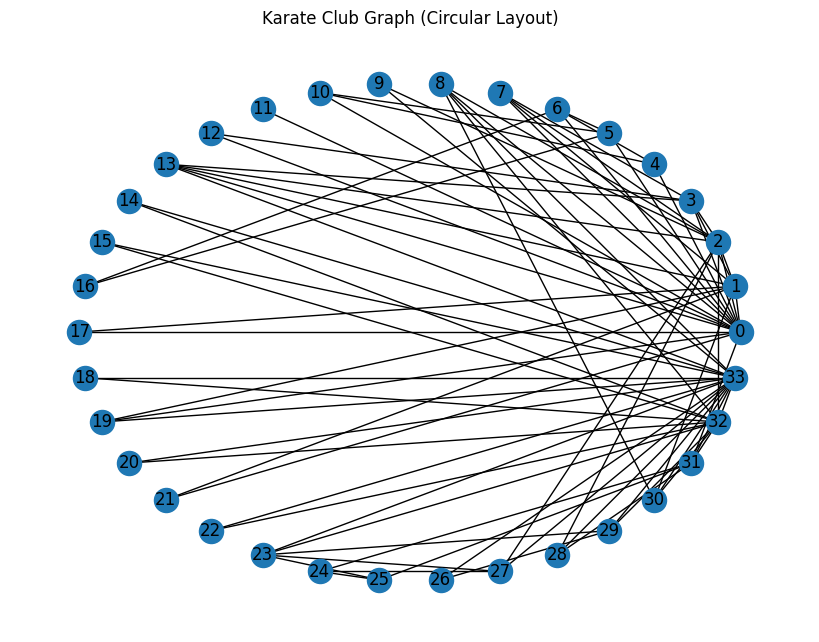

In [13]:
plt.figure(figsize=(8, 6))
nx.draw_circular(G, with_labels=True)
plt.title("Karate Club Graph (Circular Layout)")
plt.show()

## Task 1 – Degree of each node in the network

In [15]:
for node, deg in sorted(degree_dict.items()):
    print(f"Node {node:2d}: degree {deg}")

print("\nStatistics:")
print(f"Min degree: {degrees.min()}")
print(f"Max degree: {degrees.max()}")
print(f"Average degree: {degrees.mean():.2f}")

Node  0: degree 16
Node  1: degree 9
Node  2: degree 10
Node  3: degree 6
Node  4: degree 3
Node  5: degree 4
Node  6: degree 4
Node  7: degree 4
Node  8: degree 5
Node  9: degree 2
Node 10: degree 3
Node 11: degree 1
Node 12: degree 2
Node 13: degree 5
Node 14: degree 2
Node 15: degree 2
Node 16: degree 2
Node 17: degree 2
Node 18: degree 2
Node 19: degree 3
Node 20: degree 2
Node 21: degree 2
Node 22: degree 2
Node 23: degree 5
Node 24: degree 3
Node 25: degree 3
Node 26: degree 2
Node 27: degree 4
Node 28: degree 3
Node 29: degree 4
Node 30: degree 4
Node 31: degree 6
Node 32: degree 12
Node 33: degree 17

Statistics:
Min degree: 1
Max degree: 17
Average degree: 4.59


## Task 2 – Graph plot scaled by degree
Plot the graph in such a way that size of a node is scaled according to their respective
degree i.e.; the node having higher degree will be bigger in size as compared to a node
having lower degree.[Hint: use the node_size attribute of the network.draw() function]

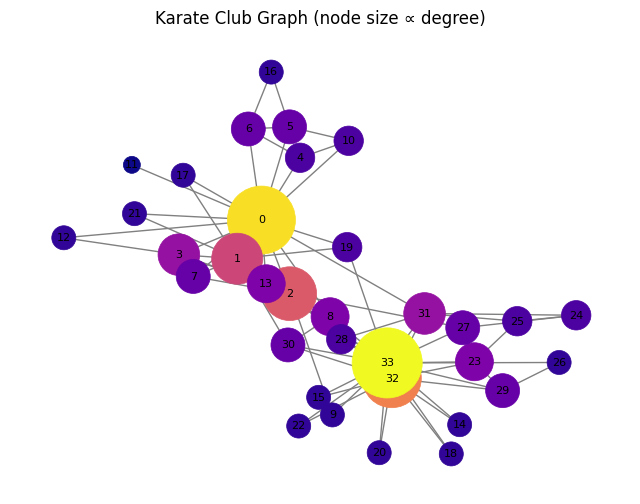

In [ ]:

plt.figure(figsize=(8, 6))
layout = nx.spring_layout(G, seed=42)
node_sizes = [degree_dict[n] * 150 for n in G.nodes()]
colors = degrees  # coloring by degree  (lighter color = higher degree)
nx.draw_networkx(G,pos=layout,with_labels=True,node_size=node_sizes,node_color=colors,
                 cmap=plt.cm.plasma,edge_color="gray",linewidths=0.5,font_size=8,
)
plt.title("Karate Club Graph (node size ∝ degree)")
plt.axis("off")
plt.show()

## Task 3 – Degree distribution histogram

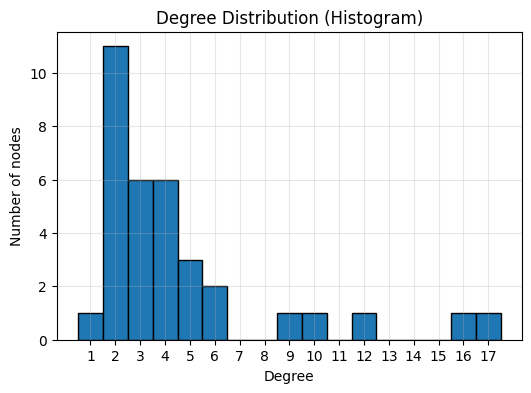

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(degrees, bins=range(degrees.min(), degrees.max() + 2), align="left", edgecolor="black")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution (Histogram)")
plt.xticks(range(degrees.min(), degrees.max() + 1))
plt.grid(alpha=0.3)
plt.show()

## Task 4 – Cumulative degree distribution function (CDDF) of the graph

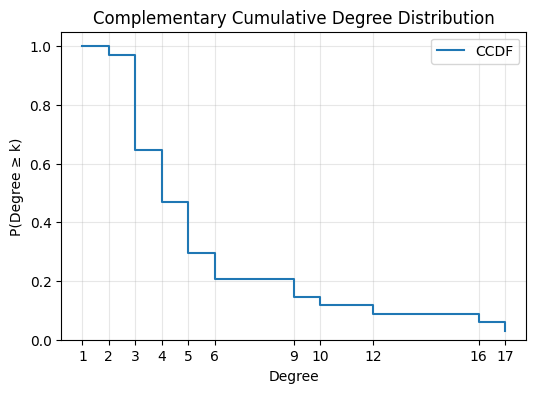

In [ ]:
# CCFD P(Degree ≥ k) = 1 - P(Degree < k) where P(Degree < k) is the CDF of the degree distribution, k is degree value
counts = Counter(degrees)
degree_values = sorted(counts.keys())
counts_array = np.array([counts[d] for d in degree_values])
# CCDF: P(X >= x)
ccdf = 1 - np.cumsum(counts_array) / counts_array.sum() + counts_array / counts_array.sum()

plt.figure(figsize=(6, 4))
plt.step(degree_values, ccdf, where="post", label="CCDF")
plt.xlabel("Degree")
plt.ylabel("P(Degree ≥ k)")
plt.title("Complementary Cumulative Degree Distribution")
plt.xticks(degree_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Task 5 – Local clustering coefficient example and manual verification


In [ ]:
# Pickinf a random node for verification
# formulas used: C = (2 * E) / (k * (k - 1)) where E = existing edges among neighbors, k = degree of node
node = 0
neighbors = list(G.neighbors(node))
k = len(neighbors)
subgraph = G.subgraph(neighbors)
existing_edges = subgraph.number_of_edges()
possible_edges = k * (k - 1) / 2
manual_cc = existing_edges / possible_edges if possible_edges > 0 else 0.0

nx_cc = nx.clustering(G, node)

print(f"Node {node} degree (k): {k}")
print(f"Edges among neighbors: {existing_edges}")
print(f"Possible edges among neighbors: {possible_edges}")
print(f"Manual clustering coefficient: {manual_cc:.4f}")
print(f"NetworkX clustering coefficient: {nx_cc:.4f}")

Node 0 degree (k): 16
Edges among neighbors: 18
Possible edges among neighbors: 120.0
Manual clustering coefficient: 0.1500
NetworkX clustering coefficient: 0.1500


## Task 6 – Diameter, density, and average path length

In [ ]:
# Global network measures (connected graph assumed)
is_connected = nx.is_connected(G)
print(f"Graph connected: {is_connected}")

if is_connected:
    diameter = nx.diameter(G)
    avg_path_length = nx.average_shortest_path_length(G)
else:
    # For completeness; karate graph is connected
    diameter = None
    avg_path_length = None

density = nx.density(G)

print(f"Diameter: {diameter}")  # Print diameter (longest shortest path)
if avg_path_length is not None:
    print(f"Average path length: {avg_path_length:.4f}") # average path length (mean shortest path between all pairs)
else:
    print("Average path length: N/A")
print(f"Density: {density:.4f}") # Density = 2E / (N(N-1)) where E = number of edges, N = number of nodes

Graph connected: True
Diameter: 5
Average path length: 2.4082
Density: 0.1390
